# Compare TensorBoard Scalars Across Runs and Phases

This notebook is a clean V1 for comparing TensorBoard scalar logs across multiple training runs.

It focuses on 6 core parts:

1. Imports and plotting setup  
2. User config  
3. Discovery of TensorBoard event files  
4. Tag inspection  
5. Overlay plotting  
6. Summary table

**Design choice:** each TensorBoard event file / phase is treated as its **own series** rather than merging phases together.


In [38]:
# 1) Imports and plotting setup

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11


In [39]:
# 2) User config
# Edit this cell first when reusing the notebook.

RUN_DIRS = {
    "baselineV2": r"C:\Users\DaFalcons\Documents\TNG_Falcon\artifacts\baselineGoatTrainingV2",
    "baselineV3": r"C:\Users\DaFalcons\Documents\TNG_Falcon\artifacts\baselineGoatTrainingV3",
}

DEFAULT_TAGS = [
    "1.episode_stats (total episodes)/2.goat_win_rate",
    "1.episode_stats (total episodes)/3.tiger_win_rate",
    "1.episode_stats (total episodes)/4.max_timeout_rate",
    "1.episode_stats (total episodes)/5.repeat_timeout_rate",
    "2.window_stats (per 1000 eps)/2.goat_win_rate",
    "2.window_stats (per 1000 eps)/3.tiger_win_rate",
    "2.window_stats (per 1000 eps)/4.max_timeout_rate",
    "2.window_stats (per 1000 eps)/5.repeat_timeout_rate",
    "5.episode_reward (per 1000 eps)/1.episode_reward_mean",
]

SMOOTHING_WINDOW = .5   # 1 means no smoothing
MAX_STEP = None        # e.g. 500_000
FIGSIZE = (10, 6)


In [40]:
# 3) Discovery helpers
# These keep each event file / phase separate.

def smooth_series(y, window=1):
    if window is None or window <= 1:
        return np.array(y, dtype=float)
    return pd.Series(y).rolling(window=window, min_periods=1).mean().to_numpy()


def find_event_files(run_dir):
    run_path = Path(run_dir)
    if not run_path.exists():
        print(f"[WARN] Directory does not exist: {run_path}")
        return []
    return sorted(run_path.rglob("events.out.tfevents.*"))


def make_series_label(run_name, event_file):
    event_file = Path(event_file)
    rel_parent = event_file.parent.name
    rel_grandparent = event_file.parent.parent.name if event_file.parent.parent != event_file.parent else ""

    if rel_grandparent:
        return f"{run_name} | {rel_grandparent}/{rel_parent}"
    return f"{run_name} | {rel_parent}"


def get_scalar_tags(event_file):
    try:
        ea = EventAccumulator(str(event_file), size_guidance={"scalars": 0})
        ea.Reload()
        return ea.Tags().get("scalars", [])
    except Exception as e:
        print(f"[WARN] Failed to read tags from {event_file}: {e}")
        return []


def extract_scalar_df(event_file, tag):
    try:
        ea = EventAccumulator(str(event_file), size_guidance={"scalars": 0})
        ea.Reload()

        if tag not in ea.Tags().get("scalars", []):
            return pd.DataFrame(columns=["step", "value"])

        events = ea.Scalars(tag)
        df = pd.DataFrame({
            "step": [e.step for e in events],
            "value": [e.value for e in events],
        })
        return df.sort_values("step").reset_index(drop=True)

    except Exception as e:
        print(f"[WARN] Failed to extract tag '{tag}' from {event_file}: {e}")
        return pd.DataFrame(columns=["step", "value"])


all_series = []

for run_name, run_dir in RUN_DIRS.items():
    event_files = find_event_files(run_dir)
    print(f"{run_name}: found {len(event_files)} event file(s)")

    for ef in event_files:
        all_series.append({
            "run_name": run_name,
            "event_file": Path(ef),
            "series_label": make_series_label(run_name, ef),
            "tags": get_scalar_tags(ef),
        })

series_df = pd.DataFrame(all_series)
series_df


baselineV2: found 6 event file(s)
baselineV3: found 5 event file(s)


,run_name,event_file,series_label,tags
0,baselineV2,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...,baselineV2 | tb/goat_vs_greedy_tiger_50M_20260...,"[3.matchup_info/1.learner_id, 3.matchup_info/2..."
1,baselineV2,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...,baselineV2 | tb/goat_vs_smart_tiger_50M_202603...,"[3.matchup_info/1.learner_id, 3.matchup_info/2..."
2,baselineV2,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...,baselineV2 | tb/robust_goat_training_20260320_...,"[3.matchup_info/1.learner_id, 3.matchup_info/2..."
3,baselineV2,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...,baselineV2 | tb/robust_goat_training_20260320_...,"[3.matchup_info/1.learner_id, 3.matchup_info/2..."
4,baselineV2,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...,baselineV2 | tb/robust_goat_training_20260320_...,"[3.matchup_info/1.learner_id, 3.matchup_info/2..."
5,baselineV2,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...,baselineV2 | tb/robust_goat_training_20260320_...,"[3.matchup_info/1.learner_id, 3.matchup_info/2..."
6,baselineV3,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...,baselineV3 | tb/goat_vs_greedy_tiger_50M_20260...,"[3.matchup_info/1.learner_id, 3.matchup_info/2..."
7,baselineV3,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...,baselineV3 | tb/goat_vs_smart_tiger_50M_202603...,"[3.matchup_info/1.learner_id, 3.matchup_info/2..."
8,baselineV3,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...,baselineV3 | tb/robust_goat_training_20260321_...,"[3.matchup_info/1.learner_id, 3.matchup_info/2..."
9,baselineV3,C:\Users\DaFalcons\Documents\TNG_Falcon\artifa...,baselineV3 | tb/robust_goat_training_20260321_...,"[3.matchup_info/1.learner_id, 3.matchup_info/2..."


In [41]:
# 4) Tag inspection
# First check what the notebook actually found.

if series_df.empty:
    print("No event files found.")
else:
    print("Discovered series:")
    for i, row in series_df.iterrows():
        print(f"{i:2d}: {row['series_label']}")
        print(f"    {row['event_file']}")

    print("\n" + "=" * 80)
    print("Shared scalar tags across all discovered series:")
    tag_sets = [set(tags) for tags in series_df["tags"] if tags]

    if tag_sets:
        shared_tags = sorted(set.intersection(*tag_sets)) if len(tag_sets) > 1 else sorted(tag_sets[0])
        for tag in shared_tags:
            print(tag)
    else:
        print("No scalar tags found.")


Discovered series:
 0: baselineV2 | tb/goat_vs_greedy_tiger_50M_20260319_122345_phase_01
    C:\Users\DaFalcons\Documents\TNG_Falcon\artifacts\baselineGoatTrainingV2\tb\goat_vs_greedy_tiger_50M_20260319_122345_phase_01\events.out.tfevents.1773959032.Christians-Computer.21264.0
 1: baselineV2 | tb/goat_vs_smart_tiger_50M_20260319_195056_phase_01
    C:\Users\DaFalcons\Documents\TNG_Falcon\artifacts\baselineGoatTrainingV2\tb\goat_vs_smart_tiger_50M_20260319_195056_phase_01\events.out.tfevents.1773985864.Christians-Computer.21264.1
 2: baselineV2 | tb/robust_goat_training_20260320_033737_phase_01
    C:\Users\DaFalcons\Documents\TNG_Falcon\artifacts\baselineGoatTrainingV2\tb\robust_goat_training_20260320_033737_phase_01\events.out.tfevents.1774013870.Christians-Computer.21264.2
 3: baselineV2 | tb/robust_goat_training_20260320_033737_phase_02
    C:\Users\DaFalcons\Documents\TNG_Falcon\artifacts\baselineGoatTrainingV2\tb\robust_goat_training_20260320_033737_phase_02\events.out.tfevents.17

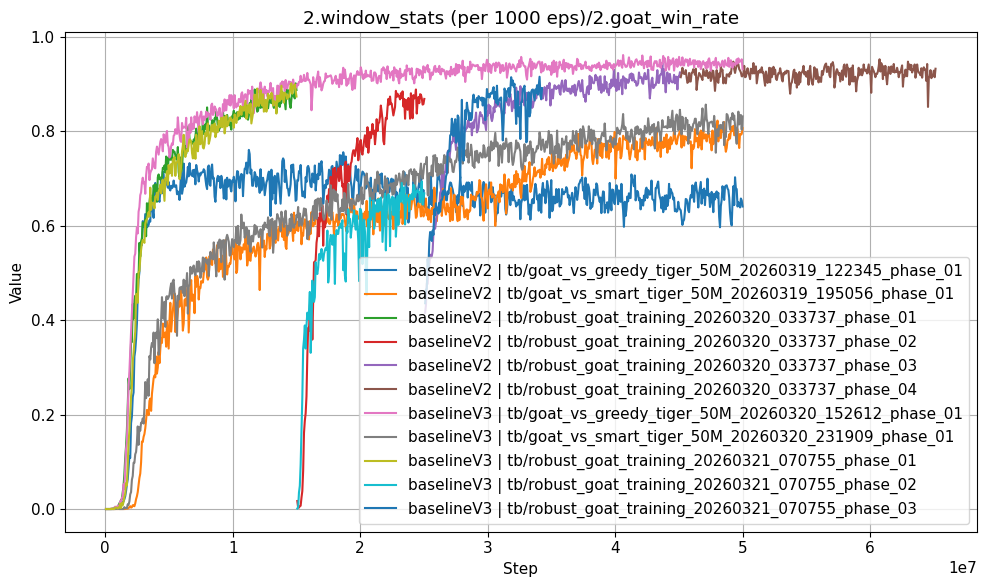

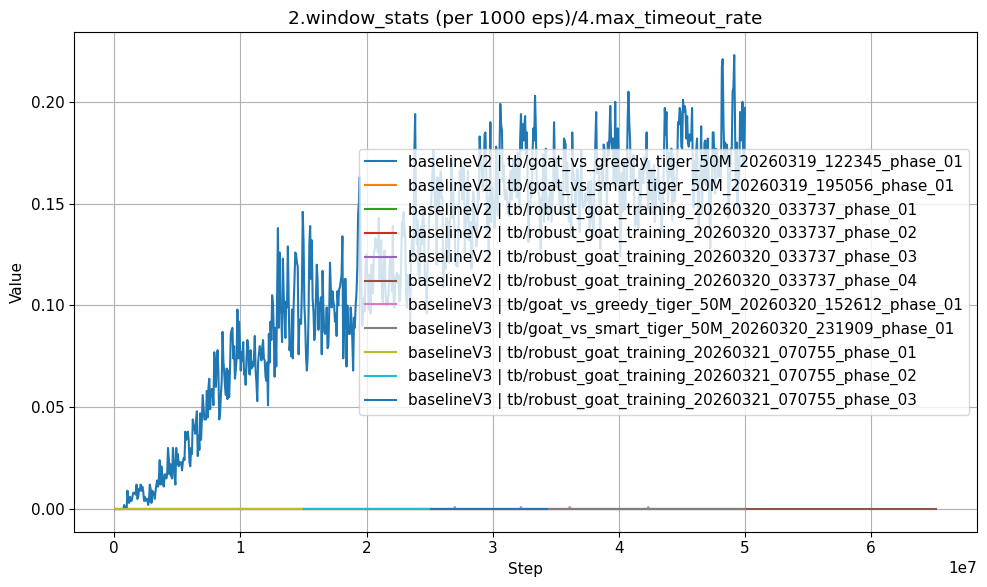

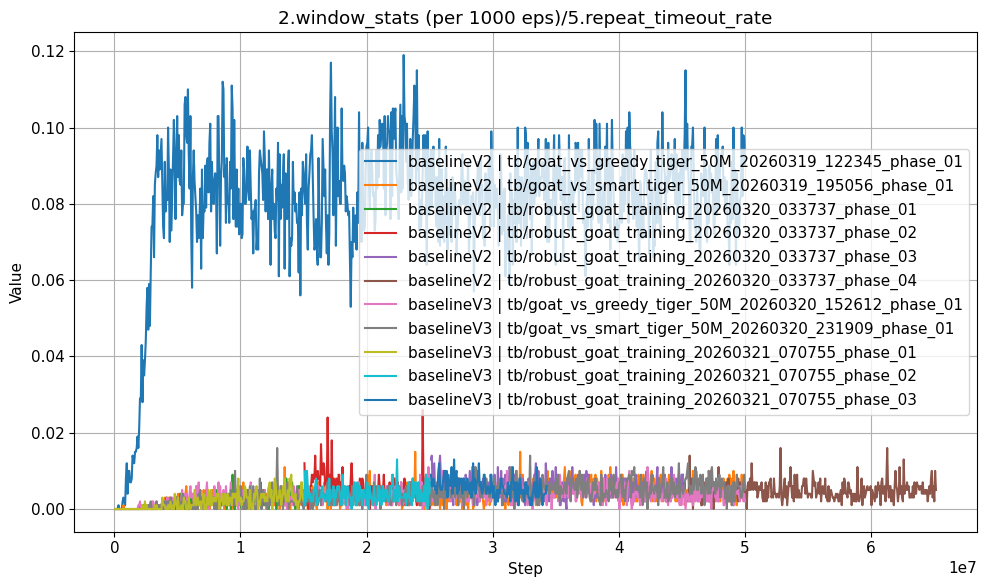

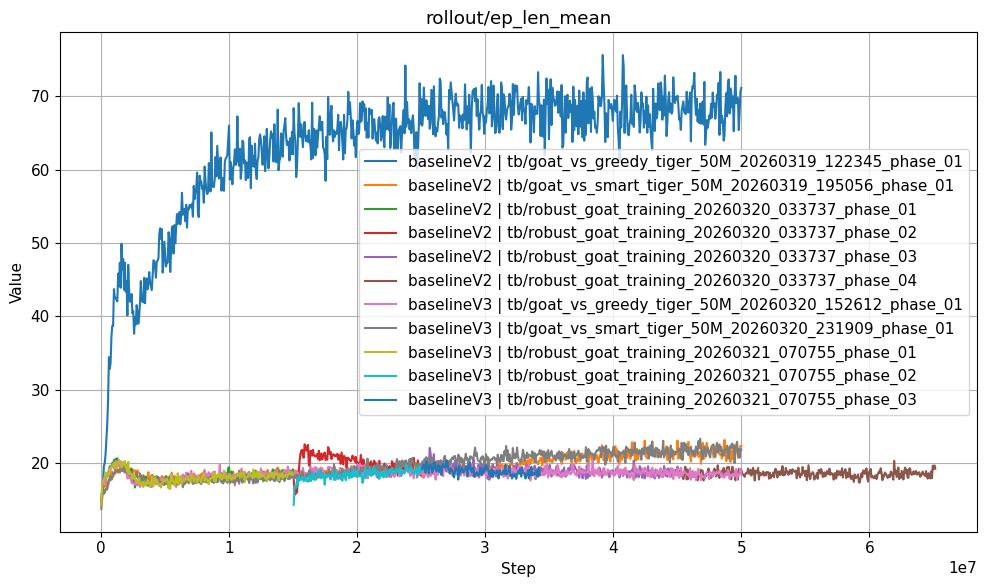

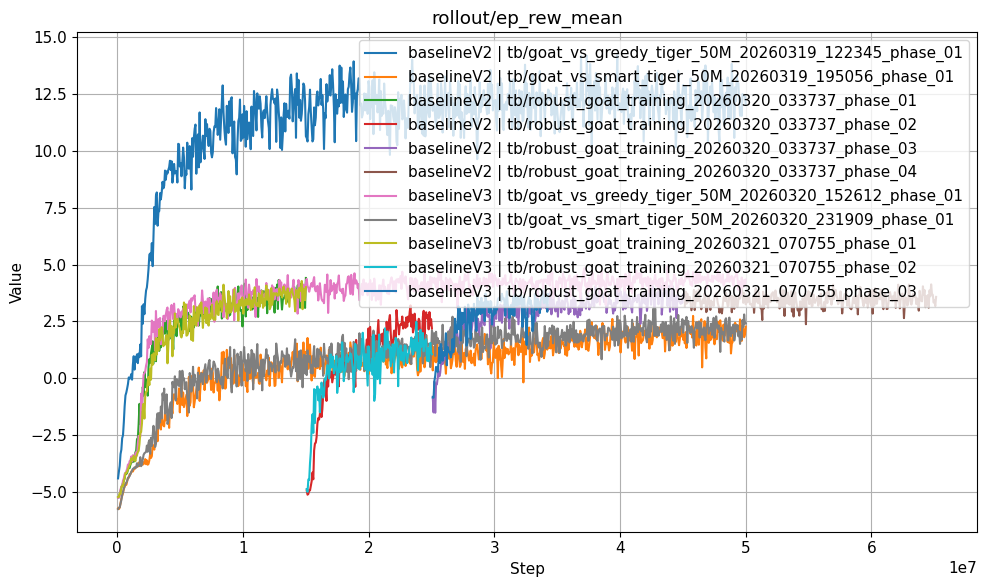

In [42]:
# 5) Overlay plotting
# Main plotting helper + a quick default loop.

def plot_tag_overlay(tag, smoothing_window=1, max_step=None, figsize=(10, 6)):
    plt.figure(figsize=figsize)
    plotted_any = False

    for _, row in series_df.iterrows():
        df = extract_scalar_df(row["event_file"], tag)
        if df.empty:
            continue

        if max_step is not None:
            df = df[df["step"] <= max_step]
        if df.empty:
            continue

        y_smooth = smooth_series(df["value"].to_numpy(), smoothing_window)
        plt.plot(df["step"], y_smooth, label=row["series_label"])
        plotted_any = True

    if not plotted_any:
        print(f"No data found for tag: {tag}")
        return

    plt.title(tag)
    plt.xlabel("Step")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()


# Example: plot one tag
plot_tag_overlay(
    tag="2.window_stats (per 1000 eps)/2.goat_win_rate",
    smoothing_window=SMOOTHING_WINDOW,
    max_step=MAX_STEP,
    figsize=FIGSIZE,
)
plot_tag_overlay(
    tag="2.window_stats (per 1000 eps)/4.max_timeout_rate",
    smoothing_window=SMOOTHING_WINDOW,
    max_step=MAX_STEP,
    figsize=FIGSIZE,
)
plot_tag_overlay(
    tag="2.window_stats (per 1000 eps)/5.repeat_timeout_rate",
    smoothing_window=SMOOTHING_WINDOW,
    max_step=MAX_STEP,
    figsize=FIGSIZE,
)
plot_tag_overlay(
    tag="rollout/ep_len_mean",
    smoothing_window=SMOOTHING_WINDOW,
    max_step=MAX_STEP,
    figsize=FIGSIZE,
)
plot_tag_overlay(
    tag="rollout/ep_rew_mean",
    smoothing_window=SMOOTHING_WINDOW,
    max_step=MAX_STEP,
    figsize=FIGSIZE,
)

#DEFAULT_TAGS = [
#    "1.episode_stats (total episodes)/2.goat_win_rate",
#    "1.episode_stats (total episodes)/3.tiger_win_rate",
#    "1.episode_stats (total episodes)/4.max_timeout_rate",
#    "1.episode_stats (total episodes)/5.repeat_timeout_rate",
#    "2.window_stats (per 1000 eps)/2.goat_win_rate",
#    "2.window_stats (per 1000 eps)/3.tiger_win_rate",
#    "2.window_stats (per 1000 eps)/4.max_timeout_rate",
#    "2.window_stats (per 1000 eps)/5.repeat_timeout_rate",
#    "5.episode_reward (per 1000 eps)/1.episode_reward_mean",
#]
# Example: plot the default set
# for tag in DEFAULT_TAGS:
#     plot_tag_overlay(
#         tag=tag,
#         smoothing_window=SMOOTHING_WINDOW,
#         max_step=MAX_STEP,
#         figsize=FIGSIZE,
#     )


In [43]:
# 6) Summary table
# Pull the final recorded value for selected tags from each series.

def build_summary_table(tags):
    rows = []

    for _, row in series_df.iterrows():
        out = {"series_label": row["series_label"]}

        for tag in tags:
            df = extract_scalar_df(row["event_file"], tag)
            out[tag] = df["value"].iloc[-1] if not df.empty else np.nan

        rows.append(out)

    return pd.DataFrame(rows)


summary_tags = [
    "1.episode_stats (total episodes)/2.goat_win_rate",
    "1.episode_stats (total episodes)/3.tiger_win_rate",
    "1.episode_stats (total episodes)/4.max_timeout_rate",
    "1.episode_stats (total episodes)/5.repeat_timeout_rate",
    "5.episode_reward (per 1000 eps)/1.episode_reward_mean",
]

summary_df = build_summary_table(summary_tags)
summary_df


,series_label,1.episode_stats (total episodes)/2.goat_win_rate,1.episode_stats (total episodes)/3.tiger_win_rate,1.episode_stats (total episodes)/4.max_timeout_rate,1.episode_stats (total episodes)/5.repeat_timeout_rate,5.episode_reward (per 1000 eps)/1.episode_reward_mean
0,baselineV2 | tb/goat_vs_greedy_tiger_50M_20260...,0.616978,0.197658,1.085256e-01,0.076839,NaN
1,baselineV2 | tb/goat_vs_smart_tiger_50M_202603...,0.597278,0.399345,3.888155e-07,0.003377,NaN
2,baselineV2 | tb/robust_goat_training_20260320_...,0.683696,0.314365,0.000000e+00,0.001939,NaN
3,baselineV2 | tb/robust_goat_training_20260320_...,0.695605,0.298944,0.000000e+00,0.005450,NaN
4,baselineV2 | tb/robust_goat_training_20260320_...,0.852273,0.142164,9.452841e-07,0.005562,NaN
5,baselineV2 | tb/robust_goat_training_20260320_...,0.922616,0.072455,0.000000e+00,0.004929,NaN
6,baselineV3 | tb/goat_vs_greedy_tiger_50M_20260...,0.866663,0.129819,2.597069e-06,0.003515,4.139512
7,baselineV3 | tb/goat_vs_smart_tiger_50M_202603...,0.638184,0.358086,0.000000e+00,0.003730,2.328129
8,baselineV3 | tb/robust_goat_training_20260321_...,0.672843,0.325262,0.000000e+00,0.001895,3.659821
9,baselineV3 | tb/robust_goat_training_20260321_...,0.559778,0.436095,0.000000e+00,0.004127,1.415873
